**ANÁLISIS**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Cargar dataset original (crudo)
pd.set_option('display.float_format', '{:.0f}'.format)
df = pd.read_csv("dataset_clientes.csv")

Visualizamos las primeras filas del dataset para tener una comprensión general de la estructura de los datos, identificar las variables disponibles y observar el formato en que se presentan

In [2]:
# Ver primeras filas
print("Primeras filas del dataset original:")
print(df.head())



Primeras filas del dataset original:
   id_cliente fecha_registro  edad     genero  region estado_civil  \
0           1     2021-10-27    66       Otro   Norte   Divorciado   
1           2     2018-08-25    51  Masculino  Centro      Soltero   
2           3     2019-05-25    48   Femenino   Norte       Casado   
3           4     2022-04-20    54  Masculino     Sur       Casado   
4           5     2020-03-19    31       Otro  Centro      Soltero   

   ingreso_mensual  gasto_mensual  deuda_total  score_crediticio  ...  \
0           924306         524088      2448145               455  ...   
1          1384687         314260      1620569               575  ...   
2              NaN         387192      5395040               771  ...   
3           436903         417329      2999350               443  ...   
4           740856         490961      1637711               468  ...   

   ultima_compra_dias  uso_app  tipo_plan num_productos tiene_tarjeta_credito  \
0                 356 

 identificamos los tipos de datos de cada variable y detectamos la presencia de posibles valores nulos.

In [3]:
# Información general
print("\nInformación del dataset:")
print(df.info())


Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20400 entries, 0 to 20399
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id_cliente             20400 non-null  int64  
 1   fecha_registro         20400 non-null  object 
 2   edad                   20400 non-null  int64  
 3   genero                 20400 non-null  object 
 4   region                 20400 non-null  object 
 5   estado_civil           20400 non-null  object 
 6   ingreso_mensual        19379 non-null  float64
 7   gasto_mensual          19375 non-null  float64
 8   deuda_total            20400 non-null  float64
 9   score_crediticio       19379 non-null  float64
 10  antiguedad_meses       20400 non-null  int64  
 11  frecuencia_compra      20400 non-null  int64  
 12  ultima_compra_dias     20400 non-null  int64  
 13  uso_app                20400 non-null  object 
 14  tipo_plan              20400

Esto nos permitió identificar qué variables presentaban datos faltantes y evaluar la magnitud del problema.

In [4]:
# Detección de valores nulos
print("\nValores nulos por columna:")
print(df.isnull().sum())



Valores nulos por columna:
id_cliente                  0
fecha_registro              0
edad                        0
genero                      0
region                      0
estado_civil                0
ingreso_mensual          1021
gasto_mensual            1025
deuda_total                 0
score_crediticio         1021
antiguedad_meses            0
frecuencia_compra           0
ultima_compra_dias          0
uso_app                     0
tipo_plan                   0
num_productos               0
tiene_tarjeta_credito       0
canal_registro              0
dia_semana_registro         0
hora_registro               0
codigo_postal               0
abandono                    0
dtype: int64


Aca obtuvimos la estadistica descriptiva, analizamos medidas como la media, desviación estándar, valores mínimos y máximos, lo que nos ayudó a comprender la distribución de los datos.

In [5]:
# Estadísticas descriptivas
# variables numéricas utilizadas
cols_inicial = [
    'edad',
    'ingreso_mensual',
    'gasto_mensual',
    'score_crediticio'
]

print("\nResumen estadístico:")
pd.set_option('display.float_format', '{:.0f}'.format)
print(df[cols_inicial].describe())


Resumen estadístico:
       edad  ingreso_mensual  gasto_mensual  score_crediticio
count 20400            19379          19375             19379
mean     49           833039         399453               600
std      18           430198         150831               100
min      18           -83026        -194957               221
25%      33           634640         296753               533
50%      48           804448         398887               601
75%      64           973794         500485               668
max      79          7560936         954575               998


Realizamos gráficos como histogramas para analizar la distribución de variables clave, como el ingreso mensual. A través de esta visualización, identificamos posibles sesgos en los datos.

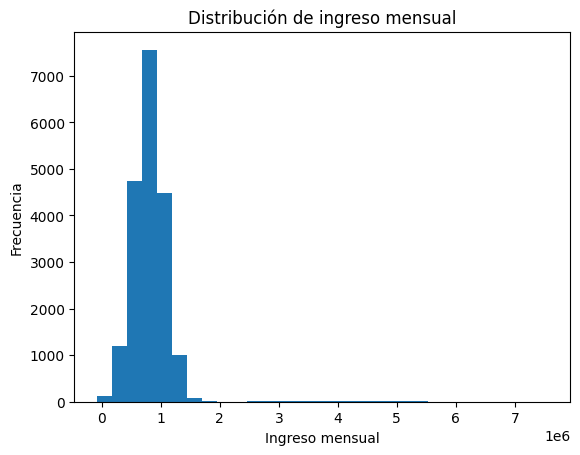

In [6]:
# Distribución de Ingresos
plt.figure()
df['ingreso_mensual'].plot(kind='hist', bins=30)
plt.title("Distribución de ingreso mensual")
plt.xlabel("Ingreso mensual")
plt.ylabel("Frecuencia")
plt.show()

Aplicamos diagramas de caja (boxplots) para identificar la presencia de valores atípicos en variables relevantes.

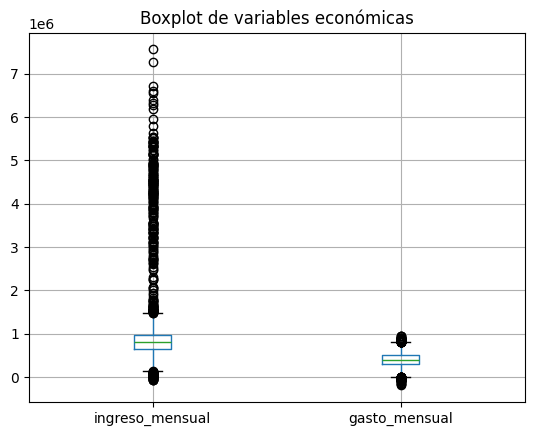

In [7]:
# Detección de Outliers
plt.figure()
df.boxplot(column=['ingreso_mensual', 'gasto_mensual'])
plt.title("Boxplot de variables económicas")
plt.show()

**LIMPIEZA DE DATOS**

implementamos una clase personalizada de limpieza de datos, la cual integramos dentro de un pipeline para automatizar el proceso.

In [8]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline

# Clase de limpieza de datos
class LimpiezaDatos(BaseEstimator, TransformerMixin):

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        df = X.copy()

        # Eliminar duplicados
        df = df.drop_duplicates(subset='id_cliente')

        # Corregir valores negativos
        df.loc[df['ingreso_mensual'] < 0, 'ingreso_mensual'] = np.nan
        df.loc[df['gasto_mensual'] < 0, 'gasto_mensual'] = np.nan

        # Imputación con mediana
        df['ingreso_mensual'] = df['ingreso_mensual'].fillna(df['ingreso_mensual'].median())
        df['gasto_mensual'] = df['gasto_mensual'].fillna(df['gasto_mensual'].median())
        df['score_crediticio'] = df['score_crediticio'].fillna(df['score_crediticio'].median())

        # Conversión de fecha
        df['fecha_registro'] = pd.to_datetime(df['fecha_registro'])

        return df

# Pipeline de limpieza
pipeline_limpieza = Pipeline([
    ('limpieza', LimpiezaDatos())
])

**TRANSFORMACIÓN DE DATOS**

implementamos una segunda clase enfocada en la transformación de los datos, aplicando técnicas de ingeniería de características.

In [9]:
# Clase de transformación
class TransformacionDatos(BaseEstimator, TransformerMixin):

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        df = X.copy()

        # Antigüedad del cliente
        df['antiguedad_dias'] = (pd.Timestamp.today() - df['fecha_registro']).dt.days

        # Ratio gasto/ingreso
        df['ratio_gasto_ingreso'] = df['gasto_mensual'] / df['ingreso_mensual']
        df['ratio_gasto_ingreso'] = df['ratio_gasto_ingreso'].replace([np.inf, -np.inf], np.nan)
        df['ratio_gasto_ingreso'] = df['ratio_gasto_ingreso'].fillna(df['ratio_gasto_ingreso'].median())

        # Limpieza de variable categórica
        df['uso_app'] = df['uso_app'].str.lower().str.strip()

        # Encoding
        df['uso_app_num'] = df['uso_app'].map({
            'bajo': 0,
            'medio': 1,
            'alto': 2
        })

        return df

# Pipeline de transformación
pipeline_transformacion = Pipeline([
    ('transformacion', TransformacionDatos())
])

integramos las etapas de limpieza y transformación dentro de un pipeline, lo que nos permitió estructurar el flujo de procesamiento de datos de manera ordenada y automatizada.

In [10]:
# Pipeline completo
pipeline_completo = Pipeline([
    ('limpieza', LimpiezaDatos()),
    ('transformacion', TransformacionDatos())
])

In [11]:
# Aplicar pipeline completo
df_procesado = pipeline_completo.fit_transform(df)

**Verificacion**

In [12]:
# Ver datos procesados
print(df_procesado.head())

   id_cliente fecha_registro  edad     genero  region estado_civil  \
0           1     2021-10-27    66       Otro   Norte   Divorciado   
1           2     2018-08-25    51  Masculino  Centro      Soltero   
2           3     2019-05-25    48   Femenino   Norte       Casado   
3           4     2022-04-20    54  Masculino     Sur       Casado   
4           5     2020-03-19    31       Otro  Centro      Soltero   

   ingreso_mensual  gasto_mensual  deuda_total  score_crediticio  ...  \
0           924306         524088      2448145               455  ...   
1          1384687         314260      1620569               575  ...   
2           804753         387192      5395040               771  ...   
3           436903         417329      2999350               443  ...   
4           740856         490961      1637711               468  ...   

   num_productos  tiene_tarjeta_credito  canal_registro dia_semana_registro  \
0              3                      1          Tienda      

In [13]:
# Ver variables utilizadas en el analisis
cols_analisis = [
    'edad',
    'ingreso_mensual',
    'gasto_mensual',
    'score_crediticio',
    'antiguedad_dias',
    'ratio_gasto_ingreso',
    'uso_app_num',
    'abandono'
]

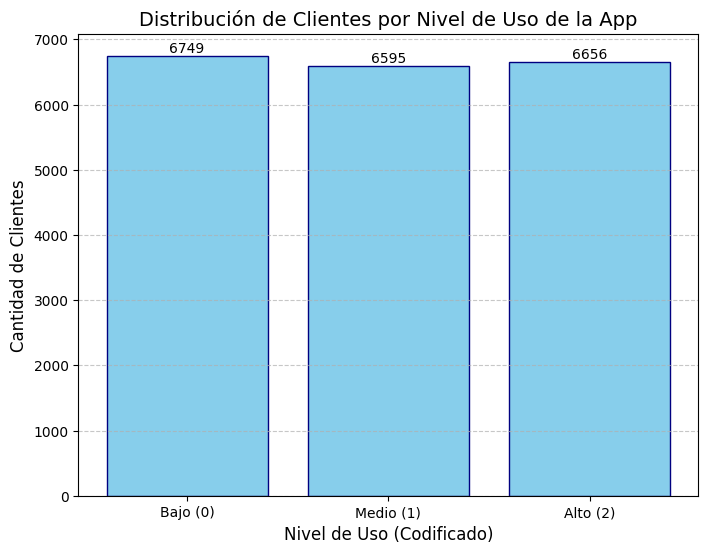

In [14]:
# Grafico de distribucion de cliente por su nivel de uso de la APP
conteo_uso = df_procesado['uso_app_num'].value_counts().sort_index()

plt.figure(figsize=(8, 6))
barras = plt.bar(['Bajo (0)', 'Medio (1)', 'Alto (2)'], conteo_uso, color='skyblue', edgecolor='navy')

for barra in barras:
    yval = barra.get_height()
    plt.text(barra.get_x() + barra.get_width()/2, yval + 0.5, yval, ha='center', va='bottom', fontsize=10)

plt.title('Distribución de Clientes por Nivel de Uso de la App', fontsize=14)
plt.xlabel('Nivel de Uso (Codificado)', fontsize=12)
plt.ylabel('Cantidad de Clientes', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)


plt.show()

In [15]:
# Resumen estadístico
print("\nResumen estadístico:")
print(df_procesado[cols_analisis].describe())



Resumen estadístico:
       edad  ingreso_mensual  gasto_mensual  score_crediticio  \
count 20000            20000          20000             20000   
mean     49           831809         400971               601   
std      18           416623         144817                98   
min      18             3442            527               221   
25%      33           645334         304441               537   
50%      48           804753         399466               601   
75%      64           963724         494276               664   
max      79          7560936         954575               998   

       antiguedad_dias  ratio_gasto_ingreso  uso_app_num  abandono  
count            20000                20000        20000     20000  
mean              2014                    1            1         0  
std                577                    1            1         0  
min               1021                    0            0         0  
25%               1512                    0    

In [16]:
# Verificar inexistencia de valores nulos
print(df_procesado.isnull().sum())

id_cliente               0
fecha_registro           0
edad                     0
genero                   0
region                   0
estado_civil             0
ingreso_mensual          0
gasto_mensual            0
deuda_total              0
score_crediticio         0
antiguedad_meses         0
frecuencia_compra        0
ultima_compra_dias       0
uso_app                  0
tipo_plan                0
num_productos            0
tiene_tarjeta_credito    0
canal_registro           0
dia_semana_registro      0
hora_registro            0
codigo_postal            0
abandono                 0
antiguedad_dias          0
ratio_gasto_ingreso      0
uso_app_num              0
dtype: int64


In [17]:
# Exportar dataset limpio
df.to_csv("dataset_clientes_limpio.csv", index=False)